In [103]:
import mne 
import pandas as pd
import numpy as np
import pathlib
from braindecode.preprocessing import create_windows_from_events

In [66]:
raw = mne.io.read_raw_bdf(r"C:\Users\Marcio Neves\Documents\Doutorado\dados\Motor_imagery\EDVALDO CAVALCANTE DE QUEIROZ.bdf")

Extracting BDF parameters from C:\Users\Marcio Neves\Documents\Doutorado\dados\Motor_imagery\EDVALDO CAVALCANTE DE QUEIROZ.bdf...
Setting channel info structure...
Creating raw.info structure...


In [67]:
print(raw)

<RawBDF | EDVALDO CAVALCANTE DE QUEIROZ.bdf, 73 x 936960 (915.0 s), ~73 KiB, data not loaded>


In [68]:
raw

<RawBDF | EDVALDO CAVALCANTE DE QUEIROZ.bdf, 73 x 936960 (915.0 s), ~73 KiB, data not loaded>

In [69]:
n_time_samps = raw.n_times
print(n_time_samps)

936960


In [70]:
time_secs = raw.times
print(time_secs)

[0.00000000e+00 9.76562500e-04 1.95312500e-03 ... 9.14997070e+02
 9.14998047e+02 9.14999023e+02]


In [71]:
ch_names = raw.ch_names
print(ch_names)

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P8', 'P6', 'P10', 'PO8', 'PO4', 'O2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status']


In [72]:
n_chan = len(ch_names)
print(n_chan)

73


In [73]:
print(
    f"the (cropped) sample data object has {n_time_samps} time samples and "
    f"{n_chan} channels."
)
print(f"The last time sample is at {time_secs[-1]} seconds.")
print("The first few channel names are {}.".format(", ".join(ch_names[:3])))
print()  # insert a blank line in the output

# some examples of raw.info:
print("bad channels:", raw.info["bads"])  # chs marked "bad" during acquisition
print(raw.info["sfreq"], "Hz")  # sampling frequency
print(raw.info["description"], "\n")  # miscellaneous acquisition info

print(raw.info)

the (cropped) sample data object has 936960 time samples and 73 channels.
The last time sample is at 914.9990234375 seconds.
The first few channel names are Fp1, AF7, AF3.

bad channels: []
1024.0 Hz
None 

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 72 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 208.0 Hz
 meas_date: 2025-12-23 16:32:48 UTC
 nchan: 73
 projs: []
 sfreq: 1024.0 Hz
 subject_info: <subject_info | his_id: EDVALDO, sex: 0, last_name: QUEIROZ30101960>
>


In [74]:
raw_eeg = raw.copy().pick_types(eeg=True, eog=False, stim=False, exclude="bads")

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [75]:
raw_eeg.drop_channels([f"EXG{i}" for i in range(1, 9) if f"EXG{i}" in raw_eeg.ch_names])

<RawBDF | EDVALDO CAVALCANTE DE QUEIROZ.bdf, 64 x 936960 (915.0 s), ~64 KiB, data not loaded>

In [76]:
raw_eeg

<RawBDF | EDVALDO CAVALCANTE DE QUEIROZ.bdf, 64 x 936960 (915.0 s), ~64 KiB, data not loaded>

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


C:\Users\Marcio Neves\AppData\Local\Temp\ipykernel_1312\2240288316.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_eeg.compute_psd().plot() #Plotiing for every freq
c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


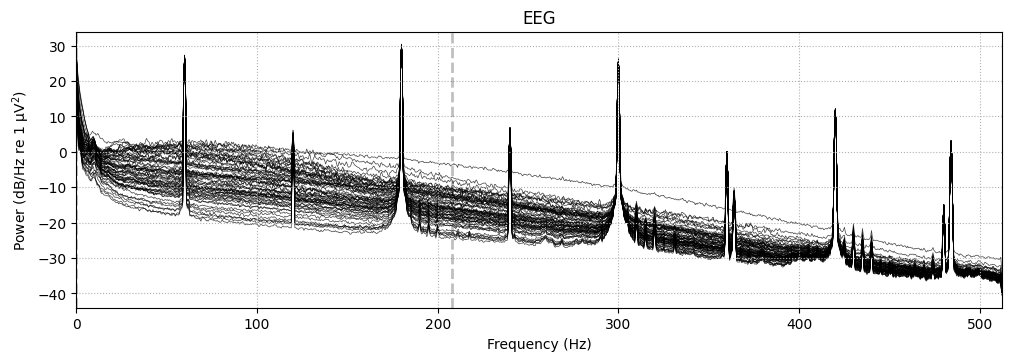

In [77]:
# Spectral estimation method: Welch (it could be multipaper but the chosen one was Welch)
raw_eeg.compute_psd().plot() #Plotiing for every freq

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


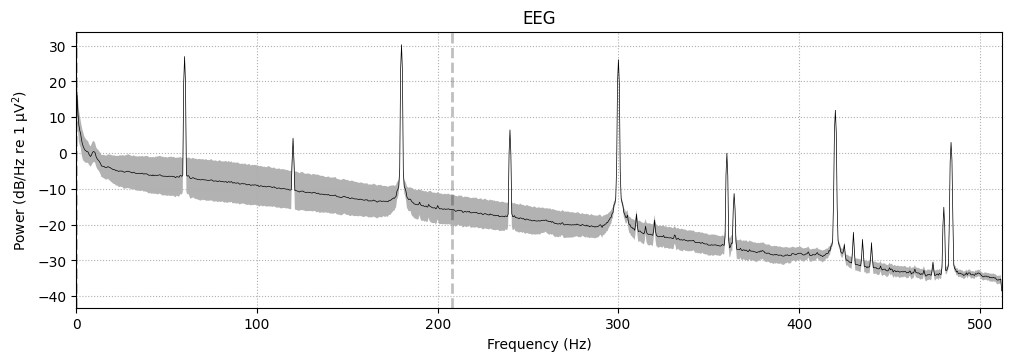

In [78]:
#Ploting the average
raw_eeg.compute_psd().plot(average=True)

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


C:\Users\Marcio Neves\AppData\Local\Temp\ipykernel_1312\1738584441.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_eeg.compute_psd(fmax=50).plot()
c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


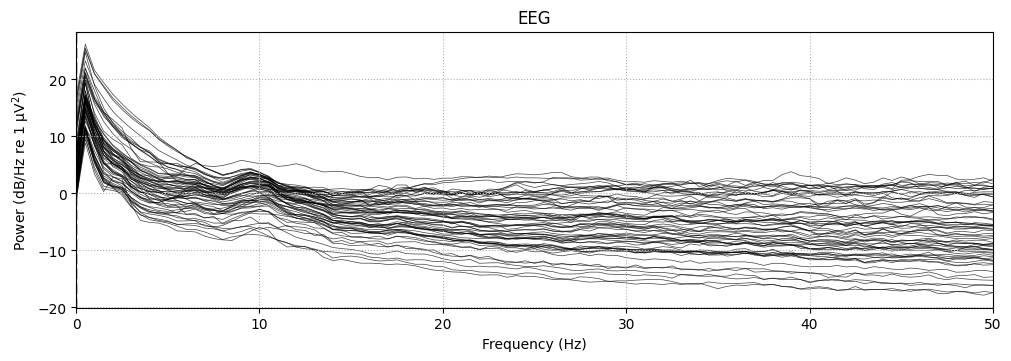

In [79]:
# Freq max: 50 Hz to spectral estimation
raw_eeg.compute_psd(fmax=50).plot() 

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


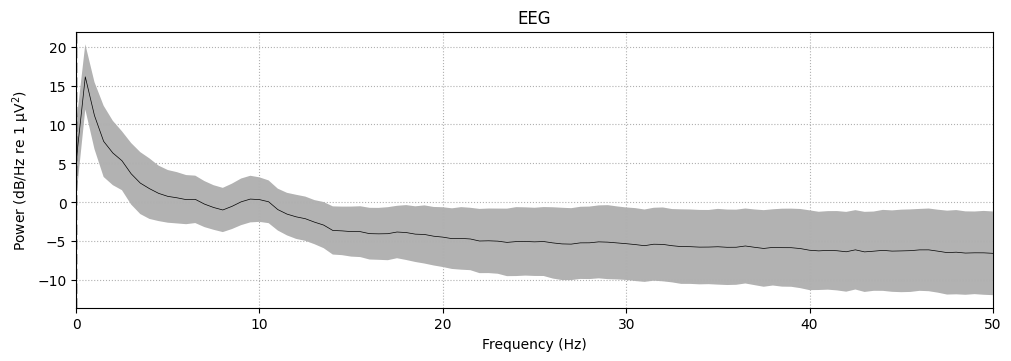

In [80]:
#Ploting the average
raw_eeg.compute_psd(fmax=50).plot(average=True) 

In [81]:
# Downsampling for 512Hz
raw_eeg.resample(sfreq = 512)

<RawBDF | EDVALDO CAVALCANTE DE QUEIROZ.bdf, 64 x 468480 (915.0 s), ~228.8 MiB, data loaded>

Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


C:\Users\Marcio Neves\AppData\Local\Temp\ipykernel_1312\3198606717.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_eeg.compute_psd().plot()
c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


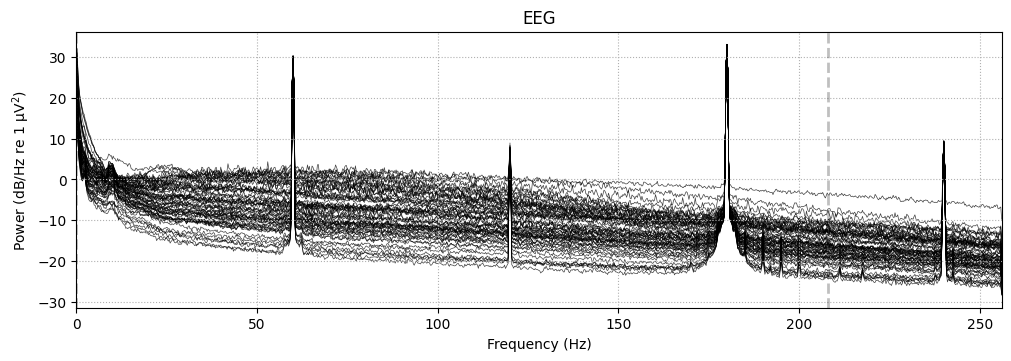

In [82]:
# Ploting downsampling spectrum
raw_eeg.compute_psd().plot()

Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


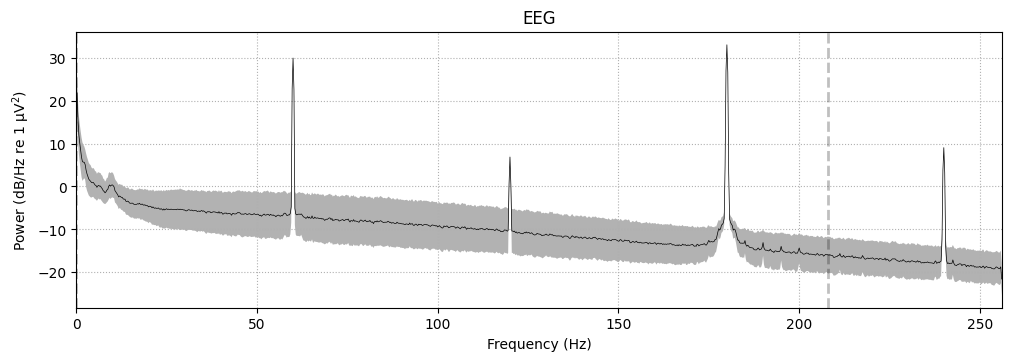

In [83]:
# Ploting downsampling spectrum
raw_eeg.compute_psd().plot(average=True)

Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


C:\Users\Marcio Neves\AppData\Local\Temp\ipykernel_1312\1027837251.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_eeg.compute_psd(fmax=50).plot()
c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


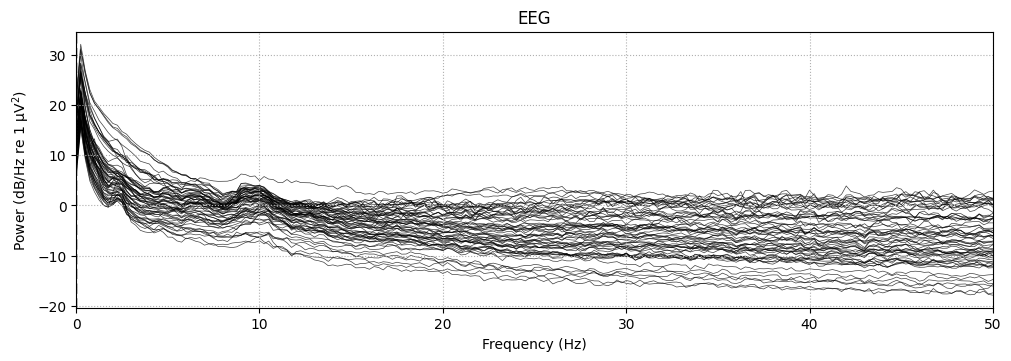

In [84]:
# Ploting downsampling spectrum
raw_eeg.compute_psd(fmax=50).plot()

Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\_mpl_figure.py:2360: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(FigureClass=FigureClass, **kwargs)
c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


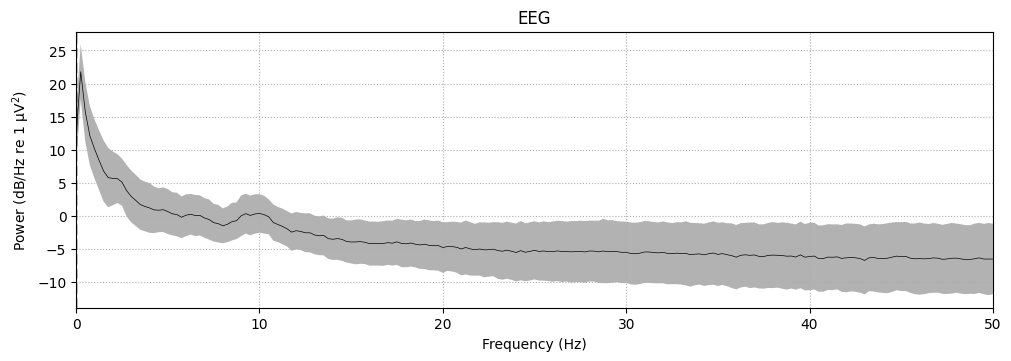

In [85]:
raw_eeg.compute_psd(fmax=50).plot(average=True)

In [ ]:
# Downsampling for 256Hz
raw_eeg.resample(sfreq = 256)

<RawBDF | EDVALDO CAVALCANTE DE QUEIROZ.bdf, 64 x 234240 (915.0 s), ~114.4 MiB, data loaded>

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


C:\Users\Marcio Neves\AppData\Local\Temp\ipykernel_1312\3198606717.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_eeg.compute_psd().plot()
c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


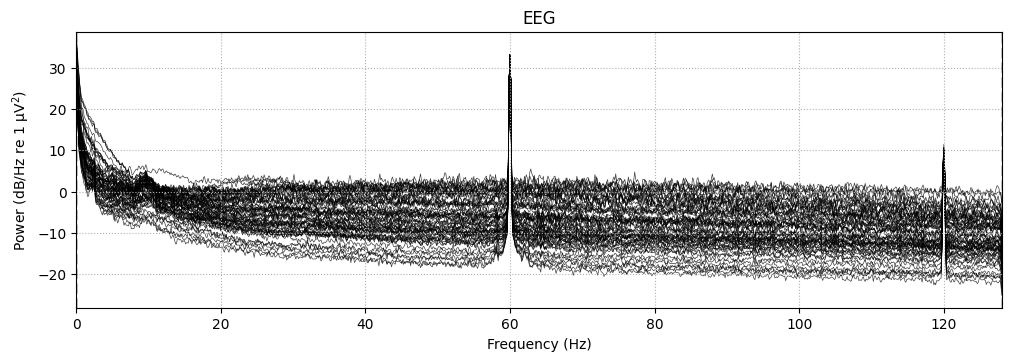

In [87]:
# Ploting downsampling spectrum
raw_eeg.compute_psd().plot()

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


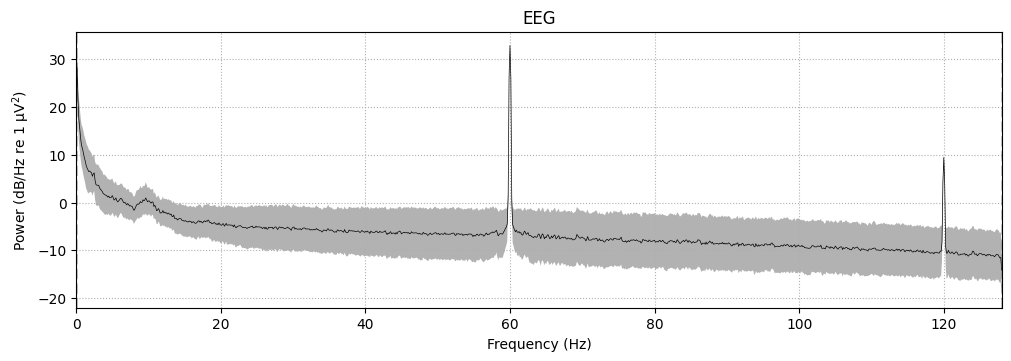

In [88]:
# Ploting downsampling spectrum
raw_eeg.compute_psd().plot(average=True)

In [93]:
raw_eeg

<RawBDF | EDVALDO CAVALCANTE DE QUEIROZ.bdf, 64 x 234240 (915.0 s), ~114.4 MiB, data loaded>

In [100]:
data = raw_eeg.get_data()

In [105]:
data.shape

(64, 234240)

In [107]:
sfreq = 256

In [116]:
import numpy as np

def transformar_em_janelas(data, tamanho_janela):
    """
    Transforma um array 2D de EEG em um array 3D usando distribuição manual dos valores.

    Entrada:
        data: array com shape (canais, amostras)

    Saída:
        data_3d: array com shape (janelas, canais, tamanho_janela)
    """

    n_canais, n_amostras = data.shape

    if n_amostras % tamanho_janela != 0:
        raise ValueError(
            f"O número de amostras ({n_amostras}) não é divisível por {tamanho_janela}."
        )

    n_janelas = n_amostras // tamanho_janela

    data_3d = np.zeros((n_janelas, n_canais, tamanho_janela))

    for janela in range(n_janelas):
        inicio = janela * tamanho_janela
        fim = inicio + tamanho_janela

        for canal in range(n_canais):
            data_3d[janela, canal, :] = data[canal, inicio:fim]

    return data_3d

In [117]:
data_3d = transformar_em_janelas(data, tamanho_janela=int(data.shape[1]/sfreq))

print(data_3d.shape)

(256, 64, 915)


In [123]:
print(f"Cada janela tem {data.shape[1]/sfreq} amostras dentro de {(data.shape[1]/sfreq)/sfreq} segundos")

Cada janela tem 915.0 amostras dentro de 3.57421875 segundos


In [124]:
segundos = (data.shape[1]/sfreq)/sfreq

In [118]:
print(data_3d)

[[[-0.00958628 -0.00961222 -0.00956382 ... -0.00952029 -0.00953513
   -0.00950596]
  [-0.01284702 -0.01284973 -0.01280603 ... -0.01285518 -0.01285799
   -0.01283212]
  [-0.02269069 -0.02269929 -0.02265522 ... -0.02267238 -0.02267904
   -0.02264966]
  ...
  [ 0.00809471  0.00810945  0.00813486 ...  0.00796525  0.00797531
    0.00800776]
  [ 0.00566052  0.00566564  0.00569707 ...  0.00552602  0.00553381
    0.0055654 ]
  [ 0.00070053  0.0007077   0.00073347 ...  0.00070209  0.00070772
    0.00074006]]

 [[-0.00949127 -0.00951735 -0.00954139 ... -0.00950063 -0.0094837
   -0.0095214 ]
  [-0.01281851 -0.01285694 -0.01287735 ... -0.01280761 -0.01279373
   -0.01283373]
  [-0.02263588 -0.02267539 -0.02269185 ... -0.02258935 -0.02258398
   -0.02261997]
  ...
  [ 0.00802612  0.00798648  0.0079808  ...  0.00800083  0.00802418
    0.00797186]
  [ 0.00557419  0.00553631  0.00553083 ...  0.0055578   0.00556484
    0.00552275]
  [ 0.00075776  0.00071666  0.00071117 ...  0.00075384  0.00077095
    0.0